<a href="https://colab.research.google.com/github/MarcoPalavicino/Challenge_DS_1/blob/main/AluraStoreLatam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Importación de datos



In [76]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_1%20.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science-latam/refs/heads/main/base-de-datos-challenge1-latam/tienda_4.csv"

tienda = pd.read_csv(url)
tienda2 = pd.read_csv(url2)
tienda3 = pd.read_csv(url3)
tienda4 = pd.read_csv(url4)

tienda.head()

,Producto,Categoría del Producto,Precio,Costo de envío,Fecha de Compra,Vendedor,Lugar de Compra,Calificación,Método de pago,Cantidad de cuotas,lat,lon
0,Asistente virtual,Electrónicos,164300.0,6900.0,16/01/2021,Pedro Gomez,Bogotá,4,Tarjeta de crédito,8,4.60971,-74.08175
1,Mesa de comedor,Muebles,192300.0,8400.0,18/05/2022,Beatriz Morales,Medellín,1,Tarjeta de crédito,4,6.25184,-75.56359
2,Juego de mesa,Juguetes,209600.0,15900.0,15/03/2021,Juan Fernandez,Cartagena,1,Tarjeta de crédito,1,10.39972,-75.51444
3,Microondas,Electrodomésticos,757500.0,41000.0,03/05/2022,Juan Fernandez,Cali,4,Nequi,1,3.43722,-76.52250
4,Silla de oficina,Muebles,335200.0,20200.0,07/11/2020,Maria Alfonso,Medellín,5,Nequi,1,6.25184,-75.56359


#1. Análisis de facturación



In [77]:
# Cálculo del ingreso total por tienda
ingreso_tienda1 = tienda['Precio'].sum()
ingreso_tienda2 = tienda2['Precio'].sum()
ingreso_tienda3 = tienda3['Precio'].sum()
ingreso_tienda4 = tienda4['Precio'].sum()

print("Ingreso tienda 1:", ingreso_tienda1)
print("Ingreso tienda 2:", ingreso_tienda2)
print("Ingreso tienda 3:", ingreso_tienda3)
print("Ingreso tienda 4:", ingreso_tienda4)


Ingreso tienda 1: 1150880400.0
Ingreso tienda 2: 1116343500.0
Ingreso tienda 3: 1098019600.0
Ingreso tienda 4: 1038375700.0


In [78]:

#  Análisis de facturación: ingreso total por tienda


# Se puede crear un DataFrame resumen
# Nota: recordar que los listados parten desde 0 en Python.
# Si quisiéramos, podríamos ajustar el formato de salida para evitar notación científica
# usando: pd.options.display.float_format = '{:,.0f}'.format

# Crear un DataFrame con los ingresos totales de cada tienda
ingresos = pd.DataFrame({
    'Tienda': ['Tienda 1', 'Tienda 2', 'Tienda 3', 'Tienda 4'],
    'Ingreso Total': [ingreso_tienda1, ingreso_tienda2, ingreso_tienda3, ingreso_tienda4]
})

# Ordenar las tiendas por mayor ingreso total
ingresos = ingresos.sort_values(by='Ingreso Total', ascending=False)

# Mostrar la tabla ordenada
display(ingresos)

# Mostrar la tienda con mayor ingreso total
tienda_top = ingresos.iloc[0]['Tienda']
print(f"\n La tienda con mayor ingreso total es: {tienda_top}")


,Tienda,Ingreso Total
0,Tienda 1,1.150880e+09
1,Tienda 2,1.116344e+09
2,Tienda 3,1.098020e+09
3,Tienda 4,1.038376e+09



 La tienda con mayor ingreso total es: Tienda 1


# 2. Ventas por categoría

In [79]:

# Ventas por categoría


# En este análisis queremos conocer cuántos productos se vendieron
# por categoría en cada tienda, y así identificar las más populares.

# 1) Agregar una etiqueta con el nombre de la tienda a cada base de datos
tienda['tienda']  = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# 2) Unir todas las ventas en una sola tabla general
ventas = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# 3) Agrupar por tienda y categoría, contando cuántos productos se vendieron
resumen_categorias = (
    ventas
    .groupby(['tienda', 'Categoría del Producto'])
    .size()
    .reset_index(name='cantidad')
)

# 4) Ordenar para ver las categorías más vendidas primero dentro de cada tienda
resumen_categorias = resumen_categorias.sort_values(['tienda', 'cantidad'], ascending=[True, False])

# 5) Mostrar la tabla principal con todas las categorías
display(resumen_categorias)

# 6) Mostrar la categoría más popular de cada tienda
top_categorias = resumen_categorias.loc[
    resumen_categorias.groupby('tienda')['cantidad'].idxmax()
].reset_index(drop=True)

print("\n Categorías más populares por tienda:")
display(top_categorias)


,tienda,Categoría del Producto,cantidad
7,Tienda 1,Muebles,465
3,Tienda 1,Electrónicos,448
5,Tienda 1,Juguetes,324
2,Tienda 1,Electrodomésticos,312
1,Tienda 1,Deportes y diversión,284
4,Tienda 1,Instrumentos musicales,182
6,Tienda 1,Libros,173
0,Tienda 1,Artículos para el hogar,171
15,Tienda 2,Muebles,442
11,Tienda 2,Electrónicos,422



 Categorías más populares por tienda:


,tienda,Categoría del Producto,cantidad
0,Tienda 1,Muebles,465
1,Tienda 2,Muebles,442
2,Tienda 3,Muebles,499
3,Tienda 4,Muebles,480


# 3. Calificación promedio de la tienda


In [80]:

#  Valoración media por tienda (paso a paso)


# A) Etiquetar cada DataFrame con el nombre de su tienda
tienda['tienda']  = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# B) Unir todo en una sola tabla
valoraciones = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# C) Asegurar que 'Calificación' es numérica (por si viene como texto)
valoraciones['Calificación'] = pd.to_numeric(valoraciones['Calificación'], errors='coerce')

# D) Promedio de calificación por tienda
promedio_valoracion = (
    valoraciones
    .groupby('tienda')['Calificación']
    .mean()
    .reset_index(name='Valoración media')
)

# E) Ordenar y mostrar
promedio_valoracion = promedio_valoracion.sort_values('Valoración media', ascending=False)
display(promedio_valoracion)

# F) Mejor tienda según valoración media
tienda_mejor_valorada = promedio_valoracion.iloc[0]['tienda']
valor_media = round(promedio_valoracion.iloc[0]['Valoración media'], 2)
print(f"\n La tienda con mayor valoración media es {tienda_mejor_valorada} con {valor_media} puntos.")


,tienda,Valoración media
2,Tienda 3,4.048326
1,Tienda 2,4.037304
3,Tienda 4,3.995759
0,Tienda 1,3.976685



 La tienda con mayor valoración media es Tienda 3 con 4.05 puntos.


# 4. Productos más y menos vendidos

In [81]:


# 🛒 Productos más vendidos y menos vendidos


# 1) Agregar una columna con el nombre de la tienda
tienda['tienda']  = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# 2) Unir todas las tiendas en una sola tabla
ventas_por_producto = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# 3) Contar cuántas veces se vendió cada producto por tienda
ventas_por_producto = (
    ventas_por_producto
    .groupby(['tienda', 'Producto'])
    .size()
    .reset_index(name='cantidad_vendida')
)

# 4) Encontrar el producto más y el menos vendido de cada tienda
productos_mas_vendidos = ventas_por_producto.loc[
    ventas_por_producto.groupby('tienda')['cantidad_vendida'].idxmax()
].reset_index(drop=True)

productos_menos_vendidos = ventas_por_producto.loc[
    ventas_por_producto.groupby('tienda')['cantidad_vendida'].idxmin()
].reset_index(drop=True)

# 5) Mostrar resultados
print(" Productos más vendidos por tienda:")
display(productos_mas_vendidos)

print("\n Productos menos vendidos por tienda:")
display(productos_menos_vendidos)


 Productos más vendidos por tienda:


,tienda,Producto,cantidad_vendida
0,Tienda 1,Armario,60
1,Tienda 2,Iniciando en programación,65
2,Tienda 3,Kit de bancas,57
3,Tienda 4,Cama box,62



 Productos menos vendidos por tienda:


,tienda,Producto,cantidad_vendida
0,Tienda 1,Auriculares con micrófono,33
1,Tienda 2,Juego de mesa,32
2,Tienda 3,Bloques de construcción,35
3,Tienda 4,Guitarra eléctrica,33


texto en cursiva# 5. Envío promedio por tienda

In [82]:

#  Valor del envío promedio por tienda


# 1) Asegurar que cada tabla tiene su columna de tienda
tienda['tienda']  = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# 2) Unir todas las tiendas en una sola tabla
envios = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# 3) Asegurar que la columna "Costo de envío" sea numérica
envios['Costo de envío'] = pd.to_numeric(envios['Costo de envío'], errors='coerce')

# 4) Calcular el costo promedio de envío por tienda
promedio_envio = (
    envios
    .groupby('tienda')['Costo de envío']
    .mean()
    .reset_index(name='Envío promedio')
)

# 5) Ordenar de mayor a menor costo promedio
promedio_envio = promedio_envio.sort_values('Envío promedio', ascending=False)

# 6) Mostrar la tabla
display(promedio_envio)

# 7) Identificar la tienda con mayor costo de envío promedio
tienda_envio_mas_alto = promedio_envio.iloc[0]['tienda']
envio_promedio_valor = round(promedio_envio.iloc[0]['Envío promedio'], 2)

print(f"\n La tienda con el envío promedio más alto es {tienda_envio_mas_alto} con un costo de ${envio_promedio_valor}.")


,tienda,Envío promedio
0,Tienda 1,26018.609580
1,Tienda 2,25216.235693
2,Tienda 3,24805.680373
3,Tienda 4,23459.457167



 La tienda con el envío promedio más alto es Tienda 1 con un costo de $26018.61.


# Visualización

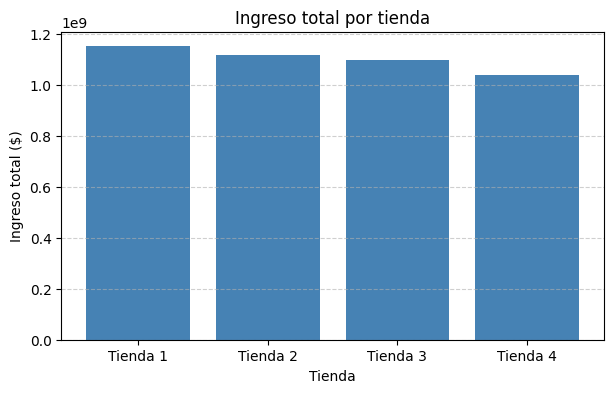

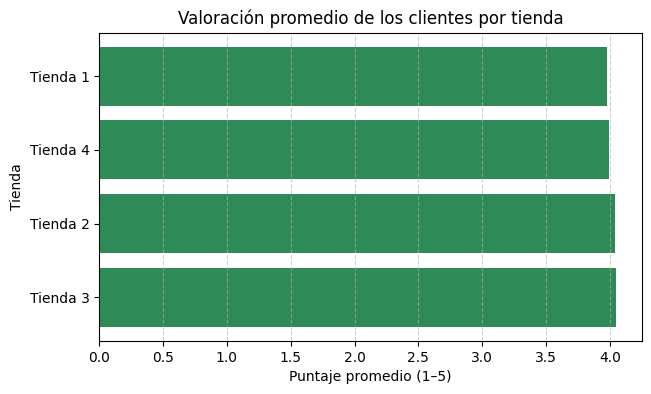

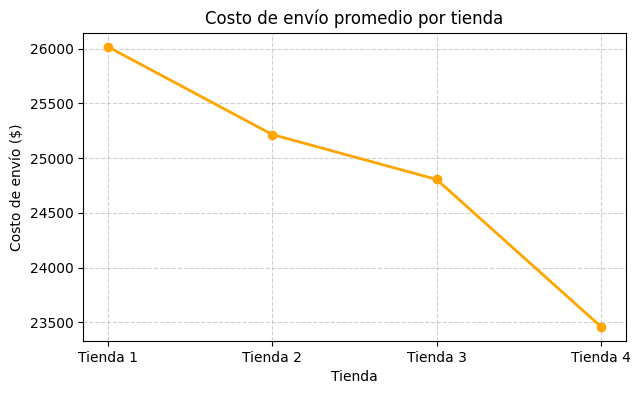

In [83]:
import matplotlib.pyplot as plt

# 1. Gráfico de barras: Ingreso total por tienda
plt.figure(figsize=(7, 4))
plt.bar(ingresos['Tienda'], ingresos['Ingreso Total'], color='steelblue')
plt.title('Ingreso total por tienda')
plt.xlabel('Tienda')
plt.ylabel('Ingreso total ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

# 2. Gráfico de barras horizontales: Valoración media por tienda
plt.figure(figsize=(7, 4))
plt.barh(promedio_valoracion['tienda'], promedio_valoracion['Valoración media'], color='seagreen')
plt.title('Valoración promedio de los clientes por tienda')
plt.xlabel('Puntaje promedio (1–5)')
plt.ylabel('Tienda')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

# 3. Gráfico de línea: Costo de envío promedio por tienda
plt.figure(figsize=(7, 4))
plt.plot(promedio_envio['tienda'], promedio_envio['Envío promedio'],
         marker='o', color='orange', linewidth=2)
plt.title('Costo de envío promedio por tienda')
plt.xlabel('Tienda')
plt.ylabel('Costo de envío ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# ***DISTRIBUCIÓN GEOGRÁFICA DE LAS VENTAS ***

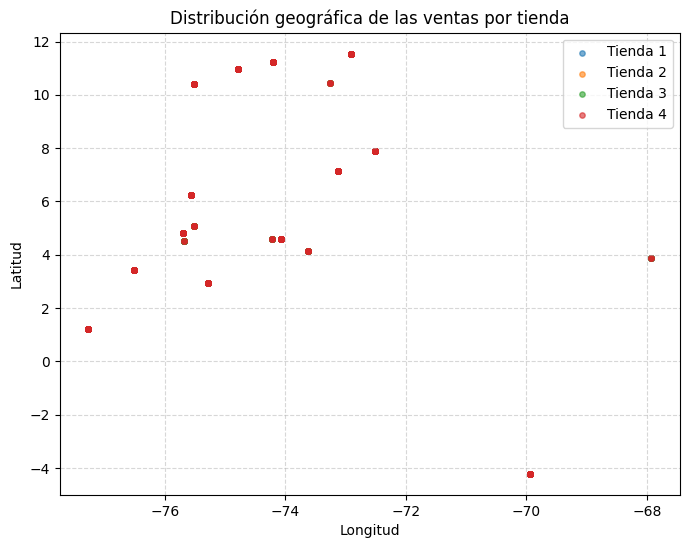

In [84]:

# DISTRIBUCIÓN GEOGRÁFICA DE LAS VENTAS


import matplotlib.pyplot as plt

# 1. Asegurar que cada tienda tenga su etiqueta
tienda['tienda']  = 'Tienda 1'
tienda2['tienda'] = 'Tienda 2'
tienda3['tienda'] = 'Tienda 3'
tienda4['tienda'] = 'Tienda 4'

# 2. Unir los datos en un solo DataFrame
ubicaciones = pd.concat([tienda, tienda2, tienda3, tienda4], ignore_index=True)

# 3. Gráfico de dispersión por tienda (latitud y longitud)
plt.figure(figsize=(8,6))
for nombre, grupo in ubicaciones.groupby('tienda'):
    plt.scatter(grupo['lon'], grupo['lat'], s=15, label=nombre, alpha=0.6)

plt.title('Distribución geográfica de las ventas por tienda')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Informe Final del Análisis

## 1. Introducción
El propósito de este análisis fue ayudar al **Sr. Juan a decidir qué tienda debería vender**.  
Para eso se analizaron los datos de cuatro tiendas, considerando los siguientes factores:

- Los ingresos totales de cada tienda.  
- Las categorías de productos más y menos vendidas.  
- Las calificaciones promedio de los clientes.  
- Los productos más y menos vendidos.  
- El costo de envío promedio.  

El objetivo fue identificar cuál tienda tiene el rendimiento más bajo en general, combinando resultados de ventas, satisfacción de clientes y costos logísticos.

---

## 2. Desarrollo del análisis

### Ingresos totales
La **Tienda 1** obtuvo el **mayor ingreso total**, mientras que la **Tienda 4** tuvo los ingresos más bajos.  
Esto indica que la Tienda 4 tiene menor movimiento económico y un nivel de ventas más bajo.

### Categorías de productos
En todas las tiendas, la categoría **“Muebles”** fue la más vendida.  
Esto muestra que el tipo de producto no es un problema, sino el rendimiento de cada tienda en particular.

### Calificaciones de los clientes
La **Tienda 3** fue la **mejor evaluada** por los clientes, con una valoración promedio cercana a **4.05 puntos**.  
La **Tienda 1** tuvo la valoración más baja, aunque sus ingresos son los más altos.  
Esto sugiere que la Tienda 3 mantiene un mejor equilibrio entre ventas y satisfacción.

### Productos más y menos vendidos
Cada tienda mostró resultados diferentes.  
Por ejemplo, la Tienda 3 tuvo como producto más vendido el *Kit de bancas* (categoría hogar), mientras que el menos vendido fue *Bloques de construcción*.  
La **Tienda 4** presentó un nivel de ventas más bajo y menos productos destacados en general.

### Costo de envío promedio
Los costos de envío son similares entre las tiendas.  
La **Tienda 3** tiene un costo promedio un poco más alto, pero esto no afecta su rendimiento, ya que mantiene altos niveles de satisfacción del cliente.

---

## 3. Conclusión
Después de revisar todos los resultados y gráficos, la tienda que el **Sr. Juan debería vender es la Tienda 4**.  
Esta tienda presenta:

- **Ingresos más bajos**.  
- **Menor volumen de ventas**.  
- **Valoraciones promedio intermedias**.  
- **Poca variedad** entre los productos más vendidos.  

En conjunto, la Tienda 4 es la que muestra el desempeño más débil.  
Por el contrario, la **Tienda 3** combina **buenas ventas, altas calificaciones** y **categorías estables**, por lo que debería mantenerse como prioridad en el negocio.

---
